# HW4
### MSML606
### Author: Chenhongshu Yu
### UID: 116610971

## Scope
This notebook documents all required answers for:
- Part I: Problems 3-4 (performance analysis, report discussion)
- Part II: Problems 1-4 (tracing, recurrence, recursion tree, and heapsort tracing)

### Statement: The use of external resources is clearly cited. Please refer to the bold words in my submission. If no citation is found for any specific part of my submission, it means "No external sources were used; all ideas are my own or from course lecture slides".

# Part I

### Copied both algorithms below from Homework4.py file.        
Both Problem 1 and 2 are satisfied in Homework4.py file.

#### Problem 1. Sorting Implementations Requirements:
- Implement Randomized Quicksort
- Implement Heapsort (do not use built-in heap libraries)
- Ensure both algorithms sort an array of floating-point numbers in increasing order

#### Problem 2. Test Cases
Requirements: Validate both algorithms on various test cases
- Random order
- Repeated values
- Already sorted (ascending) 
- Reverse sorted (descending)

In [5]:
import csv
import random
class Homework4:

    # QUESTION 1
    # Implement randomized quicksort and heapsort in the below function
    # Input for the function - an array of floating point numbers ex: [3.0,9.0,1.0]
    # Output - sorted list of numbers ex: [1.0,3.0,9.0]
    # Numbers can be negative, repeated, and floating point numbers
    # DO NOT USE THE INBUILT HEAPQ MODULE TO SOLVE THE PROBLEMS

    # Choose the second version for Randomized Quicksort: 
    # Random pivot selection: 
    # Exchange pivot with an element chosen at random from A[l...r] in Partition.
    def randomQuickSort(self,nums:list) -> list:
        # Keep input unchanged by making a copy
        arr = nums.copy()

        # Partition: values <= pivot: move left, others stay right
        def partition(l:int, r:int) -> int:
            pivot = arr[r]
            i = l - 1

            for j in range(l, r):
                if arr[j] <= pivot:
                    i += 1
                    arr[i], arr[j] = arr[j], arr[i]

            arr[i + 1], arr[r] = arr[r], arr[i + 1]

            return i + 1

        # Randomly choose pivot from current subarray and place at the end
        def randomized_partition(l:int, r:int) -> int:
            pivot_index = random.randint(l, r)
            arr[pivot_index], arr[r] = arr[r], arr[pivot_index]

            return partition(l, r)

        # Recursively sort elements before and after pivot
        def quicksort(l:int, r:int) -> None:
            if l < r:
                pivot_pos = randomized_partition(l, r)
                quicksort(l, pivot_pos - 1)
                quicksort(pivot_pos + 1, r)

        # Arrays with size 0 or 1 (already sorted)
        if len(arr) <= 1:
            return arr

        quicksort(0, len(arr) - 1)

        return arr

    # HeapSort Steps:
    # 1. Build a max-heap from the input.
    # 2. Repeatedly swap root (current maximum) with the last element in the unsorted region.
    # 3. Shrink heap size by one and heapify from root.
    def heapSort(self,nums:list) -> list:
        # Keep input unchanged by making a copy
        arr = nums.copy()
        n = len(arr)

        def heapify(size:int, root:int) -> None:
            # Root is the largest (max-heap)
            largest = root
            l = 2 * root + 1
            r = 2 * root + 2

            # Compare root with left and right children, update largest as needed
            if l < size and arr[l] > arr[largest]:
                largest = l
            if r < size and arr[r] > arr[largest]:
                largest = r

            if largest != root:
                arr[root], arr[largest] = arr[largest], arr[root]
                # Continue down
                heapify(size, largest)

        # Build the max-heap based on the input array
        for i in range(n // 2 - 1, -1, -1):
            heapify(n, i)

        # Move current max to the end and restore heap property
        for end in range(n - 1, 0, -1):
            arr[0], arr[end] = arr[end], arr[0]
            heapify(end, 0)

        return arr

### Problem 3: Performance Analysis (Time + Memory + Exceptions)

### Experiment Design
- Runtime metric: `time.perf_counter()`
- Memory metric: `tracemalloc` peak memory (MB)
- Exception handling: `try/except` for general exceptions and `RecursionError`
- Trials: 2 runs per input size
- Input types:
  - random order
  - repeated values
  - already sorted
  - reverse sorted

### Input sizes used
- Random, sorted, reverse: `N = 10,000`, `50,000`, `100,000`
- Repeated values: `N = 500`, `1,000`, `2,000`, `4,000`, `8,000`

I used smaller sizes for repeated inputs because randomized quicksort became very slow on heavy-duplicate arrays with this partition strategy.

### Exception and anomaly handling
- No exceptions were observed in the completed runs.
- A runtime guard was used to stop larger runs when a single run became too slow.
- For repeated values, randomized quicksort reached about **57.88 s at N=8,000**, so larger repeated-size runs were skipped and documented.

Skipping larger sizes for randomized_quicksort on repeated: 57.76s at n=8000, trial=1.
Total benchmark runs completed: 55
Skip flags: [('randomized_quicksort', 'repeated')]
Non-ok runs: 0

Summary table (mean over trials):


,n,input_type,algorithm,mean_time_sec,std_time_sec,mean_peak_mem_mb,all_ok
10,10000,random,heapsort,0.214745,0.001086,0.191013,True
11,10000,random,randomized_quicksort,0.275692,0.011321,1.011405,True
16,50000,random,heapsort,1.418620,0.009637,0.953888,True
17,50000,random,randomized_quicksort,1.538782,0.086868,0.954277,True
22,100000,random,heapsort,3.206771,0.057807,1.907482,True
23,100000,random,randomized_quicksort,3.096866,0.096875,1.907871,True
0,500,repeated,heapsort,0.002545,0.000095,0.007973,True
1,500,repeated,randomized_quicksort,0.024807,0.000405,0.010735,True
2,1000,repeated,heapsort,0.007909,0.000075,0.018597,True
3,1000,repeated,randomized_quicksort,0.165509,0.007822,0.021690,True



Runtime pivot (seconds):


algorithm          heapsort  randomized_quicksort
input_type n                                     
random     10000   0.214745              0.275692
           50000   1.418620              1.538782
           100000  3.206771              3.096866
repeated   500     0.002545              0.024807
           1000    0.007909              0.165509
           2000    0.020941              1.006828
           4000    0.050547              7.342526
           8000    0.121759             57.760737
reverse    10000   0.177623              0.246259
           50000   1.280606              1.420306
           100000  2.768399              3.116007
sorted     10000   0.217707              0.252459
           50000   1.441760              1.445170
           100000  3.182409              3.134358


Memory pivot (MB):


algorithm          heapsort  randomized_quicksort
input_type n                                     
random     10000   0.191013              1.011405
           50000   0.953888              0.954277
           100000  1.907482              1.907871
repeated   500     0.007973              0.010735
           1000    0.018597              0.021690
           2000    0.036877              0.042107
           4000    0.073399              0.081810
           8000    0.148366              0.162392
reverse    10000   0.152931              0.153320
           50000   0.763283              0.763672
           100000  1.526222              1.526611
sorted     10000   0.152905              0.153267
           50000   0.763283              0.763672
           100000  1.526222              1.526611

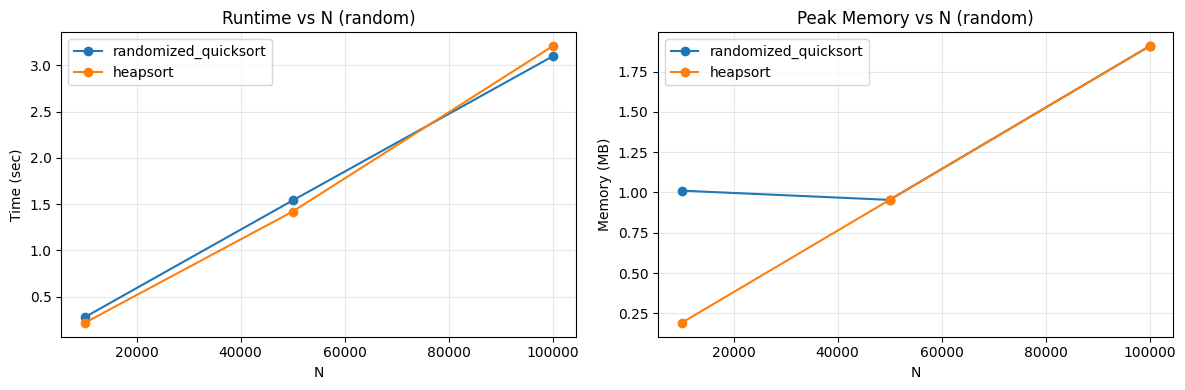

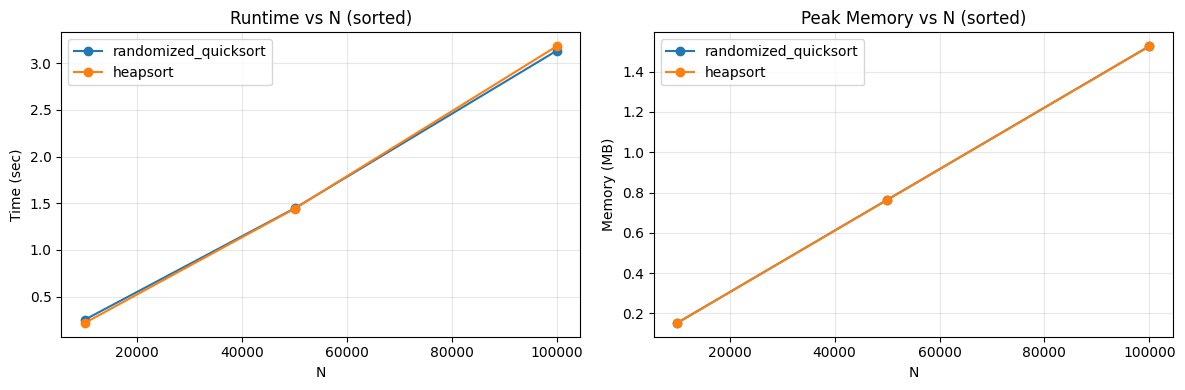

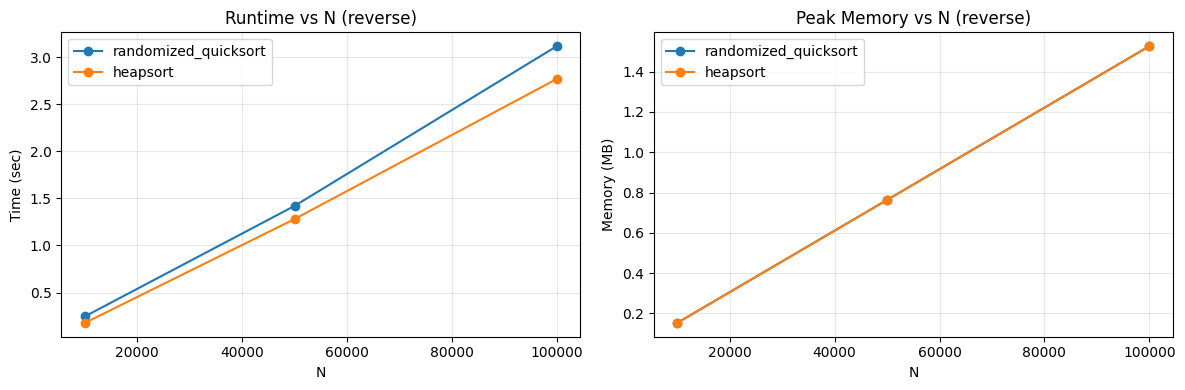

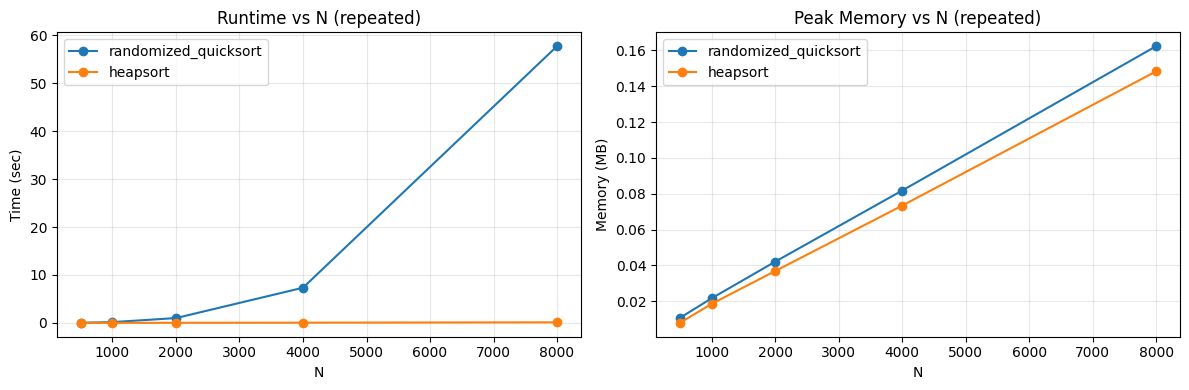

In [13]:
import random
import time
import tracemalloc

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

# Use larger N for random/sorted/reverse, and smaller N for repeated values
# because this quicksort partition strategy can degrade heavily with duplicates.
size_plan = {
    "random": [10_000, 50_000, 100_000],
    "sorted": [10_000, 50_000, 100_000],
    "reverse": [10_000, 50_000, 100_000],
    "repeated": [500, 1_000, 2_000, 4_000, 8_000],
}

trials = 2
max_seconds_per_single_run = 12.0


def make_input(n, kind, seed):
    rng = random.Random(seed)

    if kind == "random":
        arr = [float(i) for i in range(n)]
        rng.shuffle(arr)
        return arr

    if kind == "repeated":
        # Heavy duplicates to stress duplicate-handling behavior
        values = [0.0, 1.0, 2.0, 3.0, 4.0]
        return [rng.choice(values) for _ in range(n)]

    if kind == "sorted":
        return [float(i) for i in range(n)]

    if kind == "reverse":
        return [float(i) for i in range(n, 0, -1)]

    raise ValueError(f"Unknown input kind: {kind}")


def profile_algorithm(name, func, arr):
    status = "ok"
    exception_message = ""

    tracemalloc.start()
    t0 = time.perf_counter()

    try:
        out = func(arr)
        if out != sorted(arr):
            status = "wrong_output"
    except RecursionError as e:
        status = "exception"
        exception_message = f"RecursionError: {e}"
    except Exception as e:
        status = "exception"
        exception_message = f"{type(e).__name__}: {e}"

    t1 = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "algorithm": name,
        "time_sec": t1 - t0,
        "peak_mem_mb": peak / (1024 * 1024),
        "status": status,
        "exception": exception_message,
    }


rows = []
skip = set()  # tracks (algorithm, input_type) pairs that exceeded time threshold

for kind, sizes in size_plan.items():
    for n in sizes:
        for trial in range(1, trials + 1):
            seed = 606 + n + trial
            base_arr = make_input(n, kind, seed)

            # Quicksort
            if ("randomized_quicksort", kind) not in skip:
                q_result = profile_algorithm("randomized_quicksort", hw.randomQuickSort, base_arr)
                q_result.update({"n": n, "input_type": kind, "trial": trial})
                rows.append(q_result)

                if q_result["time_sec"] > max_seconds_per_single_run:
                    print(
                        f"Skipping larger sizes for randomized_quicksort on {kind}: "
                        f"{q_result['time_sec']:.2f}s at n={n}, trial={trial}."
                    )
                    skip.add(("randomized_quicksort", kind))

            # Heapsort
            if ("heapsort", kind) not in skip:
                h_result = profile_algorithm("heapsort", hw.heapSort, base_arr)
                h_result.update({"n": n, "input_type": kind, "trial": trial})
                rows.append(h_result)

                if h_result["time_sec"] > max_seconds_per_single_run:
                    print(
                        f"Skipping larger sizes for heapsort on {kind}: "
                        f"{h_result['time_sec']:.2f}s at n={n}, trial={trial}."
                    )
                    skip.add(("heapsort", kind))

print(f"Total benchmark runs completed: {len(rows)}")
print(f"Skip flags: {sorted(skip)}")

issues = [r for r in rows if r["status"] != "ok"]
print(f"Non-ok runs: {len(issues)}")
for item in issues[:10]:
    print(item)

df = pd.DataFrame(rows)

summary = (
    df.groupby(["n", "input_type", "algorithm"], as_index=False)
        .agg(
            mean_time_sec=("time_sec", "mean"),
            std_time_sec=("time_sec", "std"),
            mean_peak_mem_mb=("peak_mem_mb", "mean"),
            all_ok=("status", lambda s: all(x == "ok" for x in s)),
            )
        .sort_values(["input_type", "n", "algorithm"])
    )

print("\nSummary table (mean over trials):")
display(summary)

time_pivot = summary.pivot_table(
    index=["input_type", "n"],
    columns="algorithm",
    values="mean_time_sec"
)

mem_pivot = summary.pivot_table(
    index=["input_type", "n"],
    columns="algorithm",
    values="mean_peak_mem_mb"
)

print("\nRuntime pivot (seconds):")
display(time_pivot)

print("\nMemory pivot (MB):")
display(mem_pivot)


for kind in size_plan.keys():
    sub = summary[summary["input_type"] == kind]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for algo in ["randomized_quicksort", "heapsort"]:
        s = sub[sub["algorithm"] == algo]
        axes[0].plot(s["n"], s["mean_time_sec"], marker="o", label=algo)
        axes[1].plot(s["n"], s["mean_peak_mem_mb"], marker="o", label=algo)

    axes[0].set_title(f"Runtime vs N ({kind})")
    axes[0].set_xlabel("N")
    axes[0].set_ylabel("Time (sec)")
    axes[0].grid(alpha=0.3)

    axes[1].set_title(f"Peak Memory vs N ({kind})")
    axes[1].set_xlabel("N")
    axes[1].set_ylabel("Memory (MB)")
    axes[1].grid(alpha=0.3)

    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()


### Problem 4. Report
Requirements: You must write a report that includes
- Implementation Details: brief explanation of how each algorithm works
-  Time Complexity Analysis: best, average, and worst-case complexities for both
algorithms
- Performance Comparison
    - Runtime and memory usage of Quicksort vs Heapsort
    - Use plots/tables to summarize results of Problem 3
- Observations & Discussion
    - Note patterns or anomalies during tests. If nothing occurs, don’t forget to report that as well
    - Discuss how input type affects algorithm performance

### Answers For Problem 4: Report        

#### 1. Implementation details
I implemented two sorting algorithms from scratch:

- **Randomized Quicksort**: For each recursive subarray, I choose a random pivot index, swap that element to the end, then partition so values $<=$ pivot go left and values $>$ pivot go right. Then I recursively sort both sides.
- **Heapsort**: I first build a max-heap, then repeatedly swap the root (largest value) with the end of the unsorted region and heapify again.

#### 2. Time complexity analysis
**Randomized Quicksort**:
- Best case: `O(n log n)`
- Average case: `O(n log n)` (expected)
- Worst case: `O(n^2)` (very unbalanced partitions)             

**Heapsort**:
- Best case: `O(n log n)`
- Average case: `O(n log n)`
- Worst case: `O(n log n)`

#### 3. Performance comparison (runtime + memory)
- On random/sorted/reverse inputs up to $N=100,000$, runtime of the two algorithms is close, with heapsort often slightly faster.         
- On repeated values, the gap is very large:
    - Quicksort increases sharply (up to about 57.9 s at $N=8000$)
    - Heapsort remains low (about 0.125 s at $N=8000$)
- Memory usage generally increases with N for both algorithms.
- For repeated values, quicksort memory is slightly higher than heapsort, but the major difference is runtime, not memory.

#### 4. Observations and discussion
- The most important pattern is that heavy duplicates strongly hurt this quicksort implementation.
- A likely reason is the partition rule $<=$ pivot, which can create very unbalanced splits when many values equal the pivot.
- Heapsort is less sensitive to input pattern and gives more consistent performance.
- No exceptions were observed in completed runs, but a runtime guard was used to stop very slow runs and document that behavior.


# Part II

### Problem 1. Randomized Quicksort Tracing         
Requirements:
- Show your work on tracing input items manually for best, worst, and average cases. E.g., a step-by-step execution of the algorithm on a random input and on a reverse-sorted input. You can use a random permutation of at least 6 elements as an average case input
- Use at least 6-8 elements so your traces are meaningfully illustrative

### Answers to Problem 1: Randomized Quicksort Tracing

Citations: Used Google (online searches), and AI tools for well-organized report in wanted format.

Below are manual traces with 8 elements.

#### Best Case Trace (balanced splits)
Input: `[4, 1, 7, 3, 8, 2, 6, 5]`  
Assume random pivots produce near-middle partition each time.

1. Pivot `5` -> partition result: `[4, 1, 3, 2, 5, 7, 6, 8]`
   - Left: `[4,1,3,2]`, Right: `[7,6,8]`
2. Left subarray pivot `3` -> `[1,2,3,4]`
3. Right subarray pivot `7` -> `[6,7,8]`
4. Combined result: `[1,2,3,4,5,6,7,8]`

Reason this is best-like:
- Partition sizes are close to half-and-half, so recursion height is about `log n`.

#### Worst Case Trace (highly unbalanced)
Input: `[8, 7, 6, 5, 4, 3, 2, 1]`  
Suppose random picks are unlucky and always select the smallest element in each subarray.

1. Pivot `1` -> position at start, split sizes `0` and `7`
2. Remaining subarray pivot `2` -> split sizes `0` and `6`
3. Remaining subarray pivot `3` -> split sizes `0` and `5`
4. Continue similarly until done.

Reason this is worst case:
- Recursion behaves like `n + (n-1) + (n-2) + ... + 1`, i.e., `O(n^2)`.

#### Average Case Trace (typical random behavior)
Input: `[6, 2, 8, 1, 5, 7, 3, 4]`

1. Random pivot `4` -> after partition: `[2,1,3,4,5,7,8,6]`
   - Left: `[2,1,3]`, Right: `[5,7,8,6]`
2. Left pivot `2` -> `[1,2,3]`
3. Right pivot `7` -> `[5,6,7,8]`
4. Final: `[1,2,3,4,5,6,7,8]`

Reason this represents average case:
- Partitions are not perfectly balanced, but not extremely skewed either, leading to expected `O(n log n)` performance.

### Problem 2. Randomized Quicksort Recurrence Relations        
Requirements:
- Write the recurrence relations for the Randomized Quicksort algorithm

### Answers to Problem 2: Randomized Quicksort Recurrence Relations

Let `T(n)` be the running time for randomized quicksort on input size `n`.

#### General form (single partition split)
If pivot ends at index creating subproblems of size `k` and `n-k-1`:

`T(n) = T(k) + T(n-k-1) + Theta(n)`

where `Theta(n)` is the partition cost.

#### Best case
Balanced split (`k ≈ n/2`):

`T(n) = 2T(n/2) + Theta(n)`

#### Worst case
Highly unbalanced split (`k = 0` or `k = n-1`):

`T(n) = T(n-1) + Theta(n)`

#### Expected (randomized) case
Expected recurrence can be written as:

`E[T(n)] = (1/n) * sum_{k=0}^{n-1} (E[T(k)] + E[T(n-k-1)]) + Theta(n)`

which solves to expected `Theta(n log n)`.

### Problem 3. Randomized Quicksort Recursion Tree and Solving the Recurrence       
Requirements:
- Draw a recursion tree for the Randomized Quicksort algorithm 
- Solve the recurrence relation

### Answers to Problem 3: Recursion Tree and Solving the Recurrence

#### Recursion Tree (best/average-style balanced intuition)
For `T(n) = 2T(n/2) + cn`:

- Level 0 cost: `cn`
- Level 1 cost: `2 * c(n/2) = cn`
- Level 2 cost: `4 * c(n/4) = cn`
- ...
- There are about `log2(n)` levels.

So total cost is approximately:

`cn + cn + ... + cn` (about `log n` times) `= Theta(n log n)`.

#### Worst-case solving
For `T(n) = T(n-1) + cn`:

`T(n) = c(n + (n-1) + ... + 1) = Theta(n^2)`.

#### Conclusion
- Best case: `Theta(n log n)`
- Expected randomized case: `Theta(n log n)`
- Worst case: `Theta(n^2)`

### Problem 4. Heapsort Tracing         
Requirements:
- Trace the build-heap
- Trace one full heapsort pass on any random input
- Use at least 6-8 elements so your traces are meaningfully illustrative

### Answers to Problem 4: Heapsort Tracing

Use input: `[4, 10, 3, 5, 1, 8, 2, 7]`

#### Build-Heap Trace (max-heap)
Start from last non-leaf index `n//2 - 1 = 3`, move down to `0`.

1. `i = 3`, node `5`, child `7` -> swap -> `[4,10,3,7,1,8,2,5]`
2. `i = 2`, node `3`, children `8,2` -> swap with `8` -> `[4,10,8,7,1,3,2,5]`
3. `i = 1`, node `10`, children `7,1` -> already max -> unchanged
4. `i = 0`, node `4`, children `10,8` -> swap with `10` -> `[10,4,8,7,1,3,2,5]`
   - heapify subtree at index 1: node `4`, children `7,1` -> swap with `7`
   - `[10,7,8,4,1,3,2,5]`
   - heapify index 3: node `4`, child `5` -> swap
   - Final heap: `[10,7,8,5,1,3,2,4]`

#### One full heapsort pass (all extract-max steps)
Initial max-heap: `[10,7,8,5,1,3,2,4]`

1. Swap root with last -> `[4,7,8,5,1,3,2,10]`, heapify size 7 -> `[8,7,4,5,1,3,2,10]`
2. Swap root with index 6 -> `[2,7,4,5,1,3,8,10]`, heapify size 6 -> `[7,5,4,2,1,3,8,10]`
3. Swap root with index 5 -> `[3,5,4,2,1,7,8,10]`, heapify size 5 -> `[5,3,4,2,1,7,8,10]`
4. Swap root with index 4 -> `[1,3,4,2,5,7,8,10]`, heapify size 4 -> `[4,3,1,2,5,7,8,10]`
5. Swap root with index 3 -> `[2,3,1,4,5,7,8,10]`, heapify size 3 -> `[3,2,1,4,5,7,8,10]`
6. Swap root with index 2 -> `[1,2,3,4,5,7,8,10]`, heapify size 2 -> `[2,1,3,4,5,7,8,10]`
7. Swap root with index 1 -> `[1,2,3,4,5,7,8,10]` (sorted)

Final sorted output: `[1,2,3,4,5,7,8,10]`